In [38]:
# Базовые библиотеки
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split

# Датасеты / трансформации
import torchvision
from torchvision import transforms

print("torch:", torch.__version__)
print("torchvision:", torchvision.__version__)

torch: 2.10.0+cpu
torchvision: 0.25.0+cpu


In [39]:
def set_seed(seed: int = 42) -> None:
    # Фиксируем seed для воспроизводимости (насколько это возможно).
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # Более детерминированное поведение (может чуть замедлить).
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)
runs = [] # для runs.csv

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cpu


In [40]:
# Метрики и графики

def accuracy_from_logits(logits: torch.Tensor, y_true: torch.Tensor) -> float:
    # Accuracy для классификации: logits -> argmax -> сравнение с y_true.
    preds = torch.argmax(logits, dim=1)
    return (preds == y_true).float().mean().item()


def plot_history(history: dict, title: str = "") -> None:
    # history ожидается вида:
    # {
    #   "train_loss": [...], "val_loss": [...],
    #   "train_acc": [...],  "val_acc": [...]
    # }
    epochs = np.arange(1, len(history["train_loss"]) + 1)

    plt.figure()
    plt.plot(epochs, history["train_loss"], label="train_loss")
    plt.plot(epochs, history["val_loss"], label="val_loss")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title((title + " (loss)") if title else "loss")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure()
    plt.plot(epochs, history["train_acc"], label="train_acc")
    plt.plot(epochs, history["val_acc"], label="val_acc")
    plt.xlabel("epoch")
    plt.ylabel("accuracy")
    plt.title((title + " (accuracy)") if title else "accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()

In [41]:
# Датасет CIFAR10
# Трансформации: ToTensor и Normalize
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

# Скачиваем датасет
train_full = torchvision.datasets.CIFAR10(
    root="./data", train=True, download=True , transform=transform
)
test_ds = torchvision.datasets.CIFAR10(
    root="./data", train=False, download=True, transform=transform
)

class_names = train_full.classes
print("classes:", class_names)
print("train size:", len(train_full))
print("test size:", len(test_ds))

C:\Users\vnars\Desktop\AIE-course\pythonHW08-09\.venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
train size: 50000
test size: 10000


In [42]:
# Разбиение train/val и DataLoader

# Размер батча подстроим под наличие GPU
BATCH_SIZE = 256 if device.type == "cuda" else 64

# На Windows в Jupyter иногда бывают проблемы с multiprocessing в DataLoader.
# Поэтому автоматически ставим num_workers=0 на Windows, иначе 2.
NUM_WORKERS = 0 if os.name == "nt" else 2

# train/val split
val_ratio = 0.2
val_size = int(len(train_full) * val_ratio)
train_size = len(train_full) - val_size

gen = torch.Generator().manual_seed(42)
train_ds, val_ds = random_split(train_full, [train_size, val_size], generator=gen)

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda")
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda")
)
test_loader = DataLoader(
    test_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda")
)

# Быстрый sanity-check
x_batch, y_batch = next(iter(train_loader))
print("x_batch:", x_batch.shape, x_batch.dtype)
print("y_batch:", y_batch.shape, y_batch.dtype)

x_batch: torch.Size([64, 3, 32, 32]) torch.float32
y_batch: torch.Size([64]) torch.int64


In [43]:
# MLP модель

class MLP(nn.Module):
    def __init__(
        self,
        input_dim: int = 3 * 32 * 32, # 3* из-за rgb
        hidden_dims: tuple = (256, 128),
        num_classes: int = 10,
        activation: str = "relu",
        dropout_p: float = 0.0,
        use_batchnorm: bool = False,
    ):
        super().__init__()
        #сохранение конфига внутри модели
        self.input_dim = input_dim
        self.hidden_dims = hidden_dims
        self.activation = activation
        self.dropout_p = dropout_p
        self.use_batchnorm = use_batchnorm
        self.num_classes = num_classes

        act = activation.lower()
        if act == "relu":
            act_layer = nn.ReLU
        elif act == "tanh":
            act_layer = nn.Tanh
        elif act == "gelu":
            act_layer = nn.GELU
        else:
            raise ValueError(f"Unknown activation: {activation}")

        layers = [nn.Flatten()]

        prev = input_dim
        for h in hidden_dims:
            layers.append(nn.Linear(prev, h))
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(h))
            layers.append(act_layer())
            if dropout_p > 0:
                layers.append(nn.Dropout(p=dropout_p))
            prev = h

        layers.append(nn.Linear(prev, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

# Быстрый sanity-check по форме
model = MLP(dropout_p=0.2, use_batchnorm=True).to(device)
with torch.no_grad():
    out = model(x_batch.to(device))
print("logits:", out.shape)

logits: torch.Size([64, 10])


In [44]:
# Цикл обучения: train/eval + no_grad
# train_one_epoch – обновляет веса;
# evaluate – считает метрики на val/test без градиентов.

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()  # включаем train-режим (Dropout/BatchNorm!)
    total_loss = 0.0
    total_acc = 0.0
    n_batches = 0

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        logits = model(x)
        loss = criterion(logits, y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_acc += accuracy_from_logits(logits, y)
        n_batches += 1

    return total_loss / n_batches, total_acc / n_batches


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()  # включаем eval-режим (Dropout/BatchNorm!)
    total_loss = 0.0
    total_acc = 0.0
    n_batches = 0

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        logits = model(x)
        loss = criterion(logits, y)

        total_loss += loss.item()
        total_acc += accuracy_from_logits(logits, y)
        n_batches += 1

    return total_loss / n_batches, total_acc / n_batches

In [45]:
# если качество на validation не улучшается `patience` эпох подряд – останавливаемся и возвращаемся к лучшим весам.
# инструмент против переобучения

class EarlyStopping:
    def __init__(self, patience: int = 5, min_delta: float = 0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.best_score = None
        self.best_state = None
        self.counter = 0

    def step(self, score: float, model: nn.Module) -> bool:
        # score: чем больше, тем лучше (например, val_acc).
        # Возвращает True, если нужно остановиться.
        if self.best_score is None:
            self.best_score = score
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            return False

        if score > self.best_score + self.min_delta:
            self.best_score = score
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            self.counter = 0
            return False

        self.counter += 1
        return self.counter >= self.patience

    def restore_best(self, model: nn.Module) -> None:
        if self.best_state is not None:
            model.load_state_dict(self.best_state)


In [46]:
def fit(
    model,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    device = device,
    epochs: int = 20,
    early_stopping=None,
    verbose: bool = True,
):
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        va_loss, va_acc = evaluate(model, val_loader, criterion, device)

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)

        if verbose:
            print(
                f"epoch {epoch:02d}/{epochs} | "
                f"train loss={tr_loss:.4f}, acc={tr_acc:.4f} | "
                f"val loss={va_loss:.4f}, acc={va_acc:.4f}"
            )

        if early_stopping is not None:
            should_stop = early_stopping.step(va_acc, model)
            if should_stop:
                if verbose:
                    print(
                        f"EarlyStopping: остановка на эпохе {epoch}. "
                        f"Лучший val_acc={early_stopping.best_score:.4f}"
                    )
                early_stopping.restore_best(model)
                break

    return history

In [47]:
# функция выдающая поле `model_summary` в .csv
def summarize_model(model):
    hidden = "-".join(map(str, model.hidden_dims))
    act = model.activation
    dropout = f"dropout{model.dropout_p}" if model.dropout_p > 0 else "no_dropout"
    bn = "batchnorm" if model.use_batchnorm else "no_bn"
    return hidden, act, dropout, bn
    #return f"{hidden} {act} {dropout} {bn}"

# формирует строку в csv
def make_runs_row(exp_id, model, optimizer, history, dataset="CIFAR10", seed=42):
    opt_params = optimizer.param_groups[0]
    hidden, act, dropout, bn = summarize_model(model)
    return {
        "experiment_id": exp_id,
        "dataset": dataset,
        "seed": seed,

        "model_summary": f"{hidden} {act} {dropout} {bn}",

        "optimizer": type(optimizer).__name__,
        "lr": opt_params.get("lr"),

        "momentum": opt_params.get("momentum", "0"),
        "weight_decay": opt_params.get("weight_decay", 0),

        "epochs_trained": len(history["val_acc"]),
        "best_val_accuracy": float(np.max(history["val_acc"])),
        "best_val_loss": float(np.min(history["val_loss"]))
    }

def get_model_json(model, optimizer, history, dataset="CIFAR10", seed=42):
    opt_params = optimizer.param_groups[0]
    return {
        "dataset": dataset,
        "seed": seed,
        "model": {
            "hidden_dims": "-".join(map(str, model.hidden_dims)),
            "activation": model.activation,
            "dropout": model.dropout_p,
            "batchnorm": model.use_batchnorm,
            "num_classes": model.num_classes
        },
        "training": {
            "optimizer": type(optimizer).__name__,
            "lr": opt_params.get("lr"),
            "epochs": len(history["val_acc"]),
            "best_val_accuracy": float(np.max(history["val_acc"])),
            "best_val_loss": float(np.min(history["val_loss"]))
        }
    }

epoch 01/20 | train loss=1.6613, acc=0.4115 | val loss=1.5478, acc=0.4557
epoch 02/20 | train loss=1.4583, acc=0.4862 | val loss=1.4667, acc=0.4923
epoch 03/20 | train loss=1.3464, acc=0.5232 | val loss=1.4117, acc=0.5073
epoch 04/20 | train loss=1.2597, acc=0.5553 | val loss=1.4523, acc=0.5010
epoch 05/20 | train loss=1.1853, acc=0.5821 | val loss=1.3839, acc=0.5236
epoch 06/20 | train loss=1.1083, acc=0.6068 | val loss=1.4060, acc=0.5278
epoch 07/20 | train loss=1.0505, acc=0.6285 | val loss=1.4022, acc=0.5248
epoch 08/20 | train loss=0.9776, acc=0.6522 | val loss=1.4476, acc=0.5270
epoch 09/20 | train loss=0.9142, acc=0.6743 | val loss=1.5134, acc=0.5180
epoch 10/20 | train loss=0.8566, acc=0.6913 | val loss=1.5337, acc=0.5226
epoch 11/20 | train loss=0.8032, acc=0.7164 | val loss=1.5769, acc=0.5301
epoch 12/20 | train loss=0.7499, acc=0.7301 | val loss=1.6197, acc=0.5269
epoch 13/20 | train loss=0.7061, acc=0.7499 | val loss=1.7082, acc=0.5187
epoch 14/20 | train loss=0.6562, acc=0

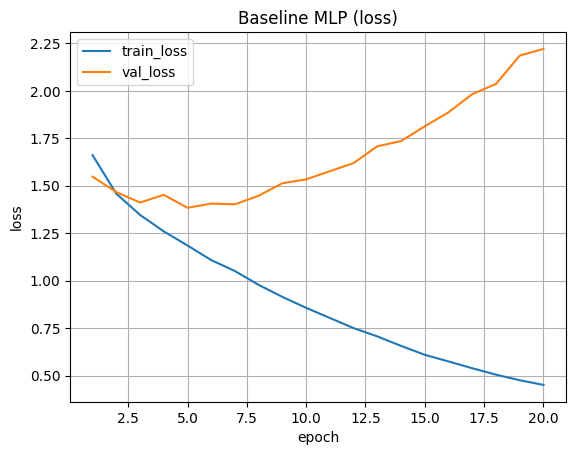

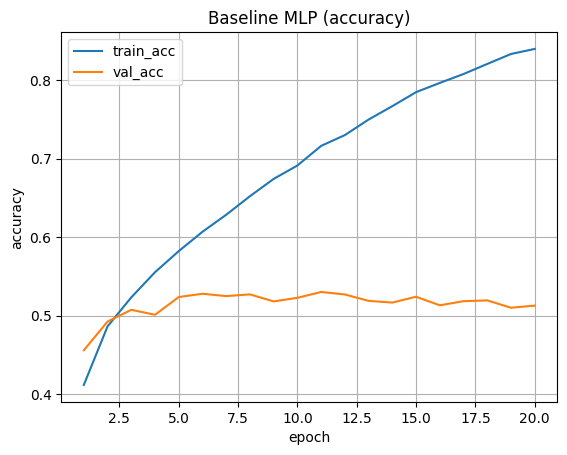

In [48]:
# E1 - Baseline: без Dropout и BatchNorm
set_seed(42)
baseline = MLP(hidden_dims=(256, 128), dropout_p=0.0, use_batchnorm=False).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(baseline.parameters(), lr=1e-3)

history_baseline = fit(
    baseline, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=20,
    early_stopping=None
)

runs.append(
    make_runs_row("E1", baseline, optimizer, history_baseline)
)

plot_history(history_baseline, title="Baseline MLP")
# Финальная проверка на test
# test_loss, test_acc = evaluate(baseline, test_loader, criterion, device)
# print(f"Baseline test: loss={test_loss:.4f}, acc={test_acc:.4f}")

epoch 01/20 | train loss=1.7898, acc=0.3621 | val loss=1.6008, acc=0.4324
epoch 02/20 | train loss=1.6390, acc=0.4213 | val loss=1.5558, acc=0.4509
epoch 03/20 | train loss=1.5818, acc=0.4398 | val loss=1.4886, acc=0.4799
epoch 04/20 | train loss=1.5344, acc=0.4576 | val loss=1.4791, acc=0.4781
epoch 05/20 | train loss=1.4913, acc=0.4735 | val loss=1.4403, acc=0.4893
epoch 06/20 | train loss=1.4602, acc=0.4839 | val loss=1.4416, acc=0.4905
epoch 07/20 | train loss=1.4338, acc=0.4901 | val loss=1.4102, acc=0.5082
epoch 08/20 | train loss=1.4074, acc=0.4957 | val loss=1.4017, acc=0.5033
epoch 09/20 | train loss=1.3913, acc=0.5037 | val loss=1.4053, acc=0.5057
epoch 10/20 | train loss=1.3634, acc=0.5126 | val loss=1.4022, acc=0.5054
epoch 11/20 | train loss=1.3463, acc=0.5173 | val loss=1.3762, acc=0.5159
epoch 12/20 | train loss=1.3282, acc=0.5248 | val loss=1.3625, acc=0.5214
epoch 13/20 | train loss=1.3091, acc=0.5309 | val loss=1.3541, acc=0.5258
epoch 14/20 | train loss=1.2903, acc=0

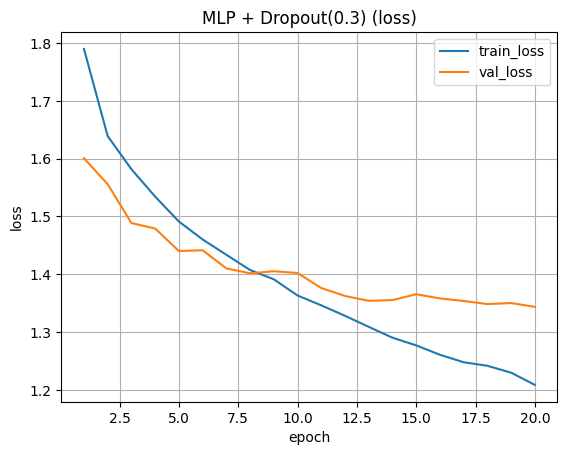

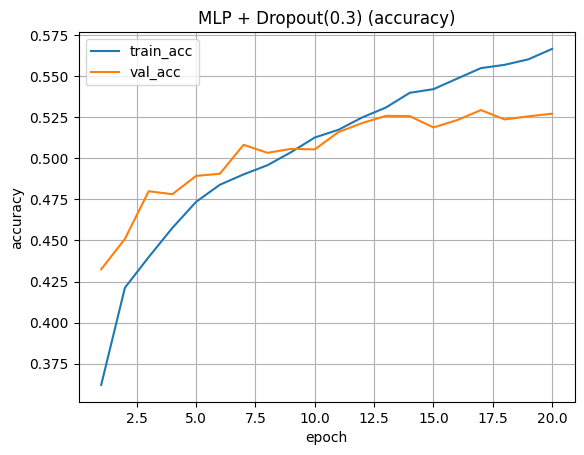

In [49]:
# E2 - Dropout

set_seed(42)
dropout_model = MLP(hidden_dims=(256, 128), dropout_p=0.3, use_batchnorm=False).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(dropout_model.parameters(), lr=1e-3)

history_dropout = fit(
    dropout_model, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=20,
    early_stopping=None
)

runs.append(
    make_runs_row("E2", dropout_model, optimizer, history_dropout)
)

plot_history(history_dropout, title="MLP + Dropout(0.3)")
# test_loss, test_acc = evaluate(dropout_model, test_loader, criterion, device)
# print(f"Dropout test: loss={test_loss:.4f}, acc={test_acc:.4f}")

epoch 01/20 | train loss=1.6365, acc=0.4173 | val loss=1.4917, acc=0.4641
epoch 02/20 | train loss=1.4247, acc=0.4906 | val loss=1.3811, acc=0.5150
epoch 03/20 | train loss=1.3239, acc=0.5266 | val loss=1.3552, acc=0.5245
epoch 04/20 | train loss=1.2471, acc=0.5541 | val loss=1.3471, acc=0.5202
epoch 05/20 | train loss=1.1789, acc=0.5807 | val loss=1.3001, acc=0.5419
epoch 06/20 | train loss=1.1189, acc=0.6023 | val loss=1.3162, acc=0.5409
epoch 07/20 | train loss=1.0658, acc=0.6212 | val loss=1.3196, acc=0.5408
epoch 08/20 | train loss=1.0122, acc=0.6414 | val loss=1.3055, acc=0.5448
epoch 09/20 | train loss=0.9613, acc=0.6585 | val loss=1.3466, acc=0.5431
epoch 10/20 | train loss=0.9155, acc=0.6747 | val loss=1.3177, acc=0.5496
epoch 11/20 | train loss=0.8653, acc=0.6957 | val loss=1.3466, acc=0.5491
epoch 12/20 | train loss=0.8280, acc=0.7054 | val loss=1.3926, acc=0.5454
epoch 13/20 | train loss=0.7824, acc=0.7225 | val loss=1.3917, acc=0.5540
epoch 14/20 | train loss=0.7423, acc=0

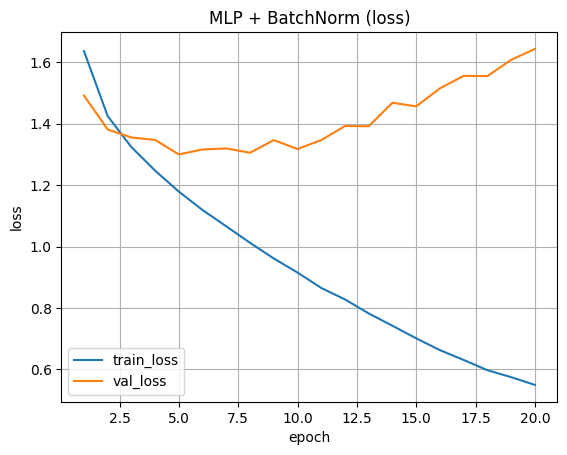

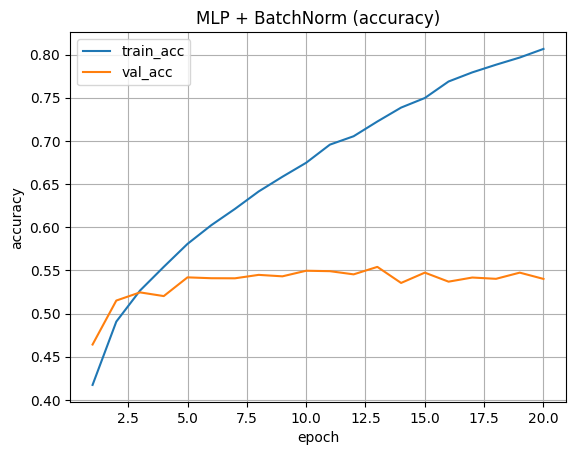

In [50]:
# E3 - BatchNorm

set_seed(42)
bn_model = MLP(hidden_dims=(256, 128), dropout_p=0.0, use_batchnorm=True).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(bn_model.parameters(), lr=1e-3)

history_bn = fit(
    bn_model, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=20,
    early_stopping=None
)

runs.append(
    make_runs_row("E3", bn_model, optimizer, history_bn)
)

plot_history(history_bn, title="MLP + BatchNorm")
# test_loss, test_acc = evaluate(bn_model, test_loader, criterion, device)
# print(f"BatchNorm test: loss={test_loss:.4f}, acc={test_acc:.4f}")

epoch 01/30 | train loss=1.6365, acc=0.4173 | val loss=1.4917, acc=0.4641
epoch 02/30 | train loss=1.4247, acc=0.4906 | val loss=1.3811, acc=0.5150
epoch 03/30 | train loss=1.3239, acc=0.5266 | val loss=1.3552, acc=0.5245
epoch 04/30 | train loss=1.2471, acc=0.5541 | val loss=1.3471, acc=0.5202
epoch 05/30 | train loss=1.1789, acc=0.5807 | val loss=1.3001, acc=0.5419
epoch 06/30 | train loss=1.1189, acc=0.6023 | val loss=1.3162, acc=0.5409
epoch 07/30 | train loss=1.0658, acc=0.6212 | val loss=1.3196, acc=0.5408
epoch 08/30 | train loss=1.0122, acc=0.6414 | val loss=1.3055, acc=0.5448
epoch 09/30 | train loss=0.9613, acc=0.6585 | val loss=1.3466, acc=0.5431
epoch 10/30 | train loss=0.9155, acc=0.6747 | val loss=1.3177, acc=0.5496
epoch 11/30 | train loss=0.8653, acc=0.6957 | val loss=1.3466, acc=0.5491
epoch 12/30 | train loss=0.8280, acc=0.7054 | val loss=1.3926, acc=0.5454
epoch 13/30 | train loss=0.7824, acc=0.7225 | val loss=1.3917, acc=0.5540
epoch 14/30 | train loss=0.7423, acc=0

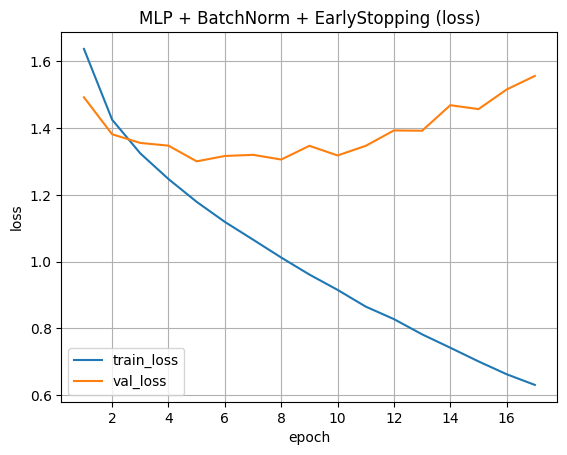

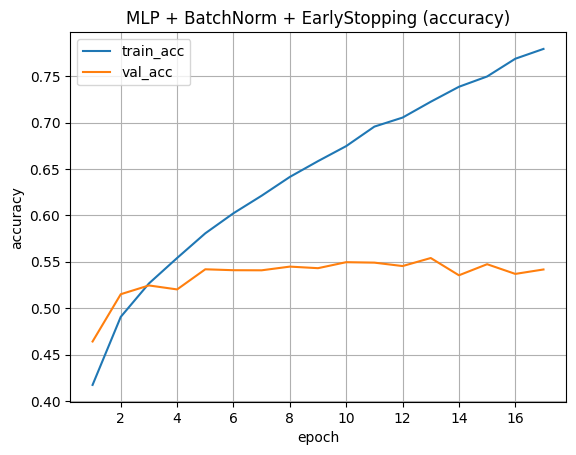

In [51]:
# из E2 и E3 лучшую метрику val_acc показала модель E3 (BatchNorm), используем ее конфиг с easystopping
# E4 - combo: MLP + BatchNorm + EarlyStopping

set_seed(42)
combo_model = MLP(hidden_dims=(256, 128), dropout_p=0.0, use_batchnorm=True).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(combo_model.parameters(), lr=1e-3)

es = EarlyStopping(patience=4, min_delta=0.0005)

history_combo = fit(
    combo_model, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=30, # дадим больше эпох, но остановимся раньше
    early_stopping=es
)

# сохранение runs.csv
runs.append(
    make_runs_row("E4", combo_model, optimizer, history_combo)
)

# сохранение best_model.pt
torch.save(combo_model.state_dict(), os.path.join("./artifacts/", "best_model.pt"))

# сохранение best_config.json
best_config = get_model_json(combo_model, optimizer, history_combo)
with open(os.path.join("./artifacts/", "best_config.json"), "w") as f:
    json.dump(best_config, f, indent=4)

plot_history(history_combo, title="MLP + BatchNorm + EarlyStopping")
# test_loss, test_acc = evaluate(bn_model, test_loader, criterion, device)
# print(f"BatchNorm test: loss={test_loss:.4f}, acc={test_acc:.4f}")

In [52]:
# график E4 в png
hist = history_combo
plt.figure(figsize=(8,5))
plt.plot(hist["train_loss"], label="train loss")
plt.plot(hist["val_loss"], label="val loss")

plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("Best model training curves (E4)")
plt.legend()

plt.savefig(os.path.join("./artifacts/figures/", "curves_best.png"))
plt.close()

In [53]:
# результаты обучения разных моделей, сравнение по test accurancy

results = {
    "baseline": evaluate(baseline, test_loader, nn.CrossEntropyLoss(), device)[1],
    "dropout": evaluate(dropout_model, test_loader, nn.CrossEntropyLoss(), device)[1],
    "batchnorm": evaluate(bn_model, test_loader, nn.CrossEntropyLoss(), device)[1],
    "combo": evaluate(combo_model, test_loader, nn.CrossEntropyLoss(), device)[1],
}

for k, v in results.items():
    print(f"{k:>9}: test_acc={v:.4f}")

 baseline: test_acc=0.5056
  dropout: test_acc=0.5314
batchnorm: test_acc=0.5339
    combo: test_acc=0.5382


In [54]:
# Часть S09

criterion = nn.CrossEntropyLoss()
EPOCHS = 6  # чисто для демонстрации этого достаточно

def make_model():
    # конфиг модели E4
    return MLP(hidden_dims=(256, 128), dropout_p=0.0, use_batchnorm=True).to(device)

def make_optimizer(model, kind, lr, weight_decay=0.0, momentum=0.9):
    kind = kind.lower().strip()
    if kind == "adam":
        return torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    if kind == "sgd":
        return torch.optim.SGD(model.parameters(), lr=lr, momentum=momentum, weight_decay=weight_decay)
    raise ValueError(f"Unknown optimizer: {kind}")

# model_E4 = make_model()
# model_E4_opt = make_optimizer(model_E4, kind="adam", lr=1e-3, weight_decay=0.0)

# hist_model_E4 = fit(
#     model_E4, train_loader, val_loader, 
#     model_E4_opt, criterion, device,
#     epochs=EPOCHS,
# )

# plot_history(hist_model_E4, title="Model E4: Adam lr=1e-3")


Experiment LR_high: Adam lr=0.1
epoch 01/6 | train loss=1.8660, acc=0.3248 | val loss=1.7222, acc=0.3760
epoch 02/6 | train loss=1.6905, acc=0.3875 | val loss=1.6131, acc=0.4223
epoch 03/6 | train loss=1.6178, acc=0.4211 | val loss=1.6060, acc=0.4247
epoch 04/6 | train loss=1.5657, acc=0.4379 | val loss=1.5788, acc=0.4390
epoch 05/6 | train loss=1.5246, acc=0.4555 | val loss=1.5202, acc=0.4675
epoch 06/6 | train loss=1.4866, acc=0.4684 | val loss=1.5625, acc=0.4441


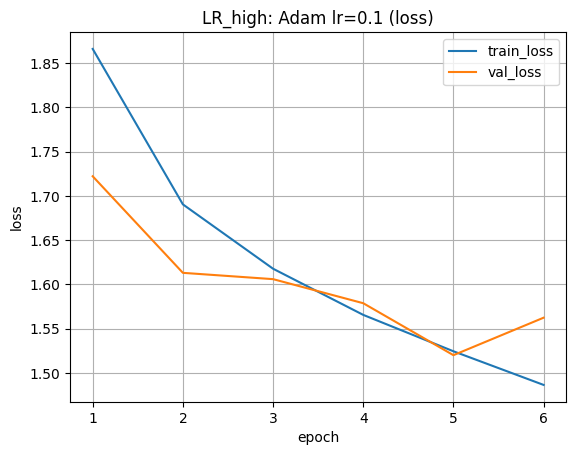

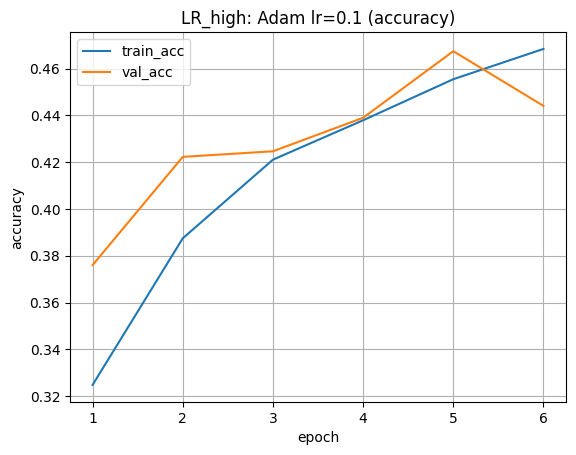


Experiment LR_low: Adam lr=1e-05
epoch 01/6 | train loss=1.9713, acc=0.3188 | val loss=1.8306, acc=0.3850
epoch 02/6 | train loss=1.7812, acc=0.4006 | val loss=1.7313, acc=0.4192
epoch 03/6 | train loss=1.6998, acc=0.4322 | val loss=1.6736, acc=0.4412
epoch 04/6 | train loss=1.6408, acc=0.4538 | val loss=1.6267, acc=0.4518
epoch 05/6 | train loss=1.5925, acc=0.4719 | val loss=1.5902, acc=0.4652
epoch 06/6 | train loss=1.5508, acc=0.4830 | val loss=1.5629, acc=0.4728


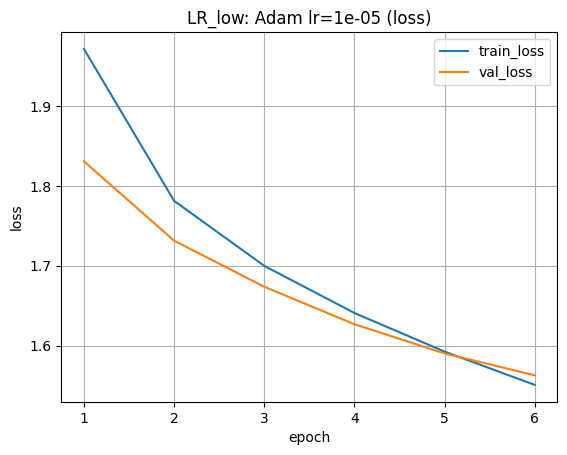

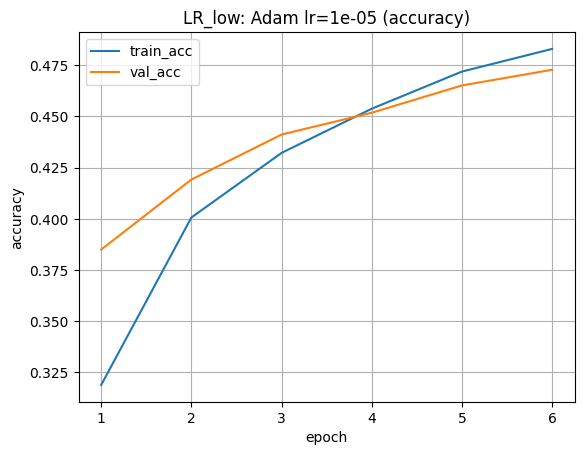

In [55]:
def run_experiment(exp_id, optimizer_kind, lr, weight_decay=0.0, momentum=0.9, epochs=EPOCHS):
    model = make_model()
    opt = make_optimizer(model, optimizer_kind, lr=lr, weight_decay=weight_decay, momentum=momentum)

    hist = fit(model, train_loader, val_loader, opt, criterion, epochs=epochs, verbose=True)

    best_val_acc = float(np.nanmax(hist["val_acc"])) if len(hist["val_acc"]) else float("nan")
    best_val_loss = float(np.nanmin(hist["val_loss"])) if len(hist["val_loss"]) else float("nan")

    return {
        "exp_id": exp_id,
        "optimizer": optimizer_kind,
        "lr": lr,
        "weight_decay": weight_decay,
        "momentum": momentum if optimizer_kind.lower() == "sgd" else None,
        "epochs_ran": len(hist["val_acc"]),
        "best_val_acc": best_val_acc,
        "best_val_loss": best_val_loss,
        "history": hist,
    }

lr_sweep = [
    ("O1", "LR_high", 1e-1),
    ("O2", "LR_low",  1e-5),
]

results = []
for exp_id, name, lr in lr_sweep:
    print("\n" + "="*80)
    print(f"Experiment {name}: Adam lr={lr}")
    res = run_experiment(exp_id=exp_id, optimizer_kind="adam", lr=lr)
    results.append(res)
    plot_history(res["history"], title=f"{name}: Adam lr={lr}")

In [56]:
# графики O1 и O2 в один png
plt.figure(figsize=(10,5))
for r in results:
    if r["exp_id"] in ["O1", "O2"]:

        plt.plot(
            r["history"]["val_loss"],
            label=f'{r["exp_id"]} (lr={r["lr"]})'
        )
plt.xlabel("epoch")
plt.ylabel("val loss")
plt.title("Learning rate extremes")
plt.legend()
plt.savefig(os.path.join("./artifacts/figures/", "curves_lr_extremes.png"))
plt.close()

Experiment SGD+momentum+weight decay: SGD lr=0.1 momentum=0.9, wd=1e-4
epoch 01/15 | train loss=1.6879, acc=0.3929 | val loss=1.5199, acc=0.4543
epoch 02/15 | train loss=1.4748, acc=0.4715 | val loss=1.4309, acc=0.4915
epoch 03/15 | train loss=1.3787, acc=0.5032 | val loss=1.3767, acc=0.5119
epoch 04/15 | train loss=1.3172, acc=0.5270 | val loss=1.3802, acc=0.5140
epoch 05/15 | train loss=1.2681, acc=0.5434 | val loss=1.3752, acc=0.5151
epoch 06/15 | train loss=1.2227, acc=0.5641 | val loss=1.3433, acc=0.5300
epoch 07/15 | train loss=1.1890, acc=0.5724 | val loss=1.3600, acc=0.5272
epoch 08/15 | train loss=1.1557, acc=0.5859 | val loss=1.3500, acc=0.5300
epoch 09/15 | train loss=1.1283, acc=0.5932 | val loss=1.3591, acc=0.5334
epoch 10/15 | train loss=1.1027, acc=0.6059 | val loss=1.3733, acc=0.5315
epoch 11/15 | train loss=1.0825, acc=0.6101 | val loss=1.3807, acc=0.5263
epoch 12/15 | train loss=1.0538, acc=0.6221 | val loss=1.3650, acc=0.5403
epoch 13/15 | train loss=1.0331, acc=0.62

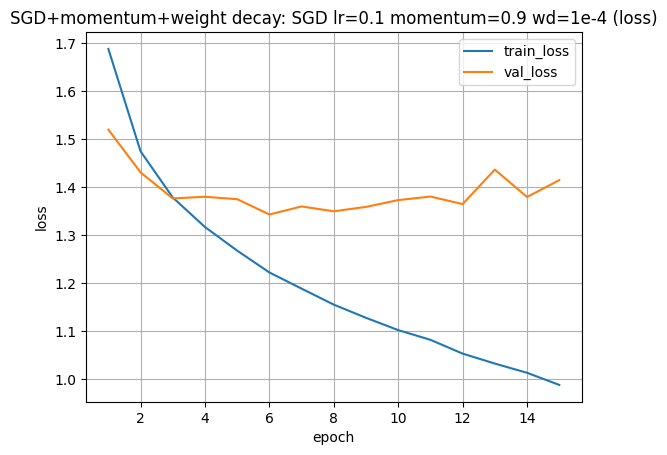

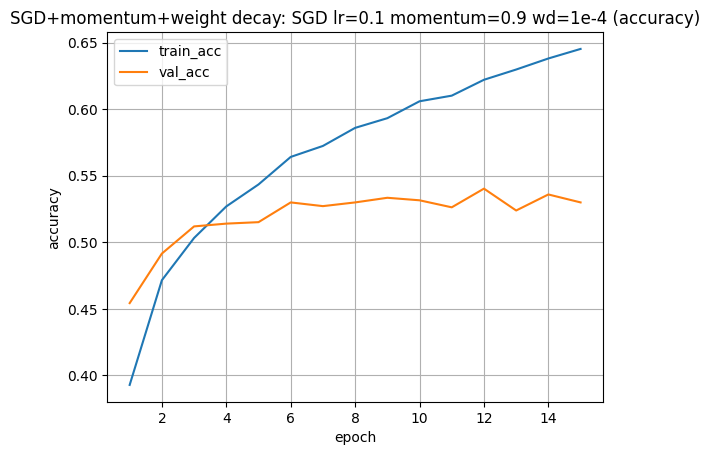

In [57]:
# SGD+momentum
print("Experiment SGD+momentum+weight decay: SGD lr=0.1 momentum=0.9, wd=1e-4")
res = run_experiment(exp_id="O3", optimizer_kind="sgd", lr=0.1, momentum=0.9, weight_decay=1e-4, epochs=15)
results.append(res)
plot_history(res["history"], title="SGD+momentum+weight decay: SGD lr=0.1 momentum=0.9 wd=1e-4")

In [58]:
rows = []
for r in results:
    res = {
        "experiment_id": r["exp_id"],
        "dataset": "CIFAR10",
        "seed": 42,
        "model_summary": "256-128 relu batchnorm",
        "optimizer": r["optimizer"],
        "lr": r["lr"],
        "momentum": r["momentum"] if r["momentum"] else "0",
        "weight_decay": r["weight_decay"],
        "epochs_trained": r["epochs_ran"],
        "best_val_accuracy": r["best_val_acc"],
        "best_val_loss": r["best_val_loss"]
    }
    runs.append(res)
    rows.append({
        "exp_id": r["exp_id"],
        "optimizer": r["optimizer"],
        "lr": r["lr"],
        "weight_decay": r["weight_decay"],
        "epochs_ran": r["epochs_ran"],
        "best_val_acc": r["best_val_acc"],
        "best_val_loss": r["best_val_loss"],
    })

df_lr = pd.DataFrame(rows)#.sort_values()(by="best_val_acc", ascending=False)
display(df_lr)

df_runs = pd.DataFrame(runs)
csv_path = os.path.join("./artifacts/", "runs.csv")
df_runs.to_csv(csv_path, index=False)

,exp_id,optimizer,lr,weight_decay,epochs_ran,best_val_acc,best_val_loss
0,O1,adam,0.10000,0.0000,6,0.467456,1.520155
1,O2,adam,0.00001,0.0000,6,0.472830,1.562867
2,O3,sgd,0.10000,0.0001,15,0.540307,1.343322
